# xfig_12 — Subject Prediction Stability Grid

Heatmap where:
- **rows** = test subjects (sorted by true_label then by prediction entropy)
- **columns** = context lengths
- **color** = mean predicted probability at K=all

A dashed line separates true-negatives (bottom) from true-positives (top).
Subjects with uniform color across columns = stable predictions.
Subjects with variable color = context-sensitive.

Idea #12 from `docs/NEW_PLOT_IDEAS.md`.

**Data**: `collected/predictions/*.parquet`.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
EXPLORE_DIR    = NSRR_TOOLS / "results" / "paper_figures" / "explore"
FINAL_OUT      = EXPLORE_DIR / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)
TABLES_DIR     = NSRR_TOOLS / "results" / "tables"

# Add explore utils to path
_nb_dir = EXPLORE_DIR / "notebooks"
sys.path.insert(0, str(_nb_dir))

from utils.data_explore import (
    set_root, load_analysis, load_analysis_all_k,
    load_heatmap, load_parquets, load_modality_table,
    subject_predictions, subject_correctness_matrix, CONTEXT_TO_MIN, CTX_ORDER,
)
from utils import panels_explore as xp

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

set_root(WORKSPACE_ROOT)
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 7,
})

# ── Constants ──────────────────────────────────────────────────────────────────
MAIN_TASKS = ["sex_binary", "bmi_binary", "age_class",
              "sleep_efficiency_binary", "apnea_binary"]
TASK_LABEL = xp.TASK_LABEL

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND'}")


WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASK         = "apnea_binary"   # most interpretable for this figure
HEAD         = "transformer"
SPLIT        = "test"
MAX_SUBJECTS = 300    # subsample if larger
CONTEXTS     = ["30s", "10m", "40m", "80m", "120m", "240m"]

pqs = load_parquets("phase0_v3", TASK, HEAD, SPLIT)
print("Contexts available:", list(pqs.keys()))
if pqs:
    n = sum(len(df["subject_id"].unique()) for df in pqs.values())
    print(f"~{n // len(pqs)} unique subjects per context")

Contexts available: ['30s', '10m', '40m', '80m', '120m', '240m']
~2054 unique subjects per context


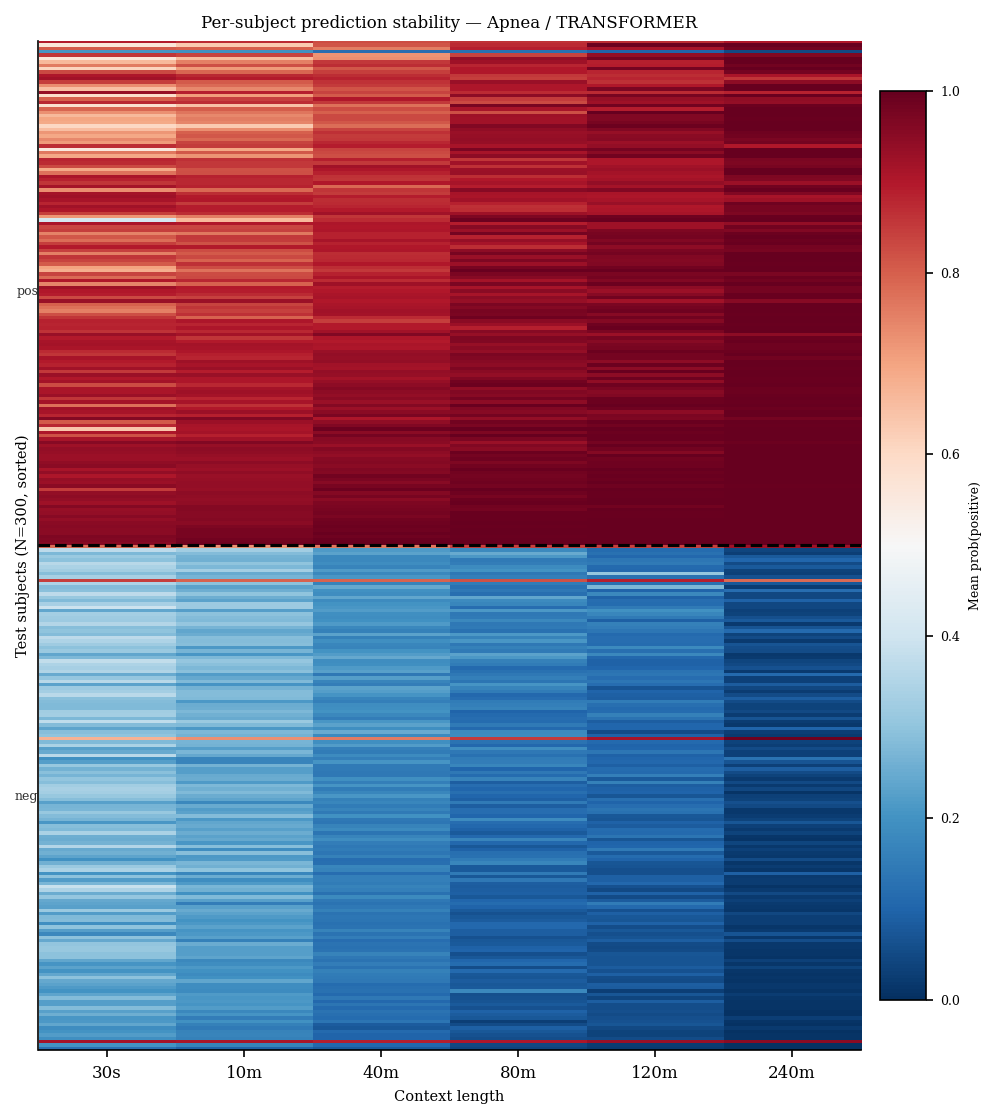

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 5.0*1.5))

xp.subject_stability_heatmap(
    ax, pqs,
    contexts=CONTEXTS,
    max_subjects=MAX_SUBJECTS,
)
ax.set_title(
    f"Per-subject prediction stability — {TASK_LABEL.get(TASK, TASK)} / {HEAD.upper()}",
    fontsize=8,
)
fig.tight_layout()
plt.show()

In [7]:
# ── Run when figure looks good ──────────────────────────────────
fig.savefig(str(FINAL_OUT / 'xfig_12_subject_stability.pdf'), bbox_inches='tight')
fig.savefig(str(FINAL_OUT / 'xfig_12_subject_stability.png'), dpi=150, bbox_inches='tight')
print('Saved →', FINAL_OUT / 'xfig_12_subject_stability.pdf')

Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/explore/final/xfig_12_subject_stability.pdf
